In [1]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import select_random_json, read_experiment_json, load_properties_bundle, create_folder
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
results_folder = "../results/conditions_effects/3D"
create_folder(results_folder)

## p(t) SERIES - $p_0$ effects for differents sizes

KeyError: 0.3

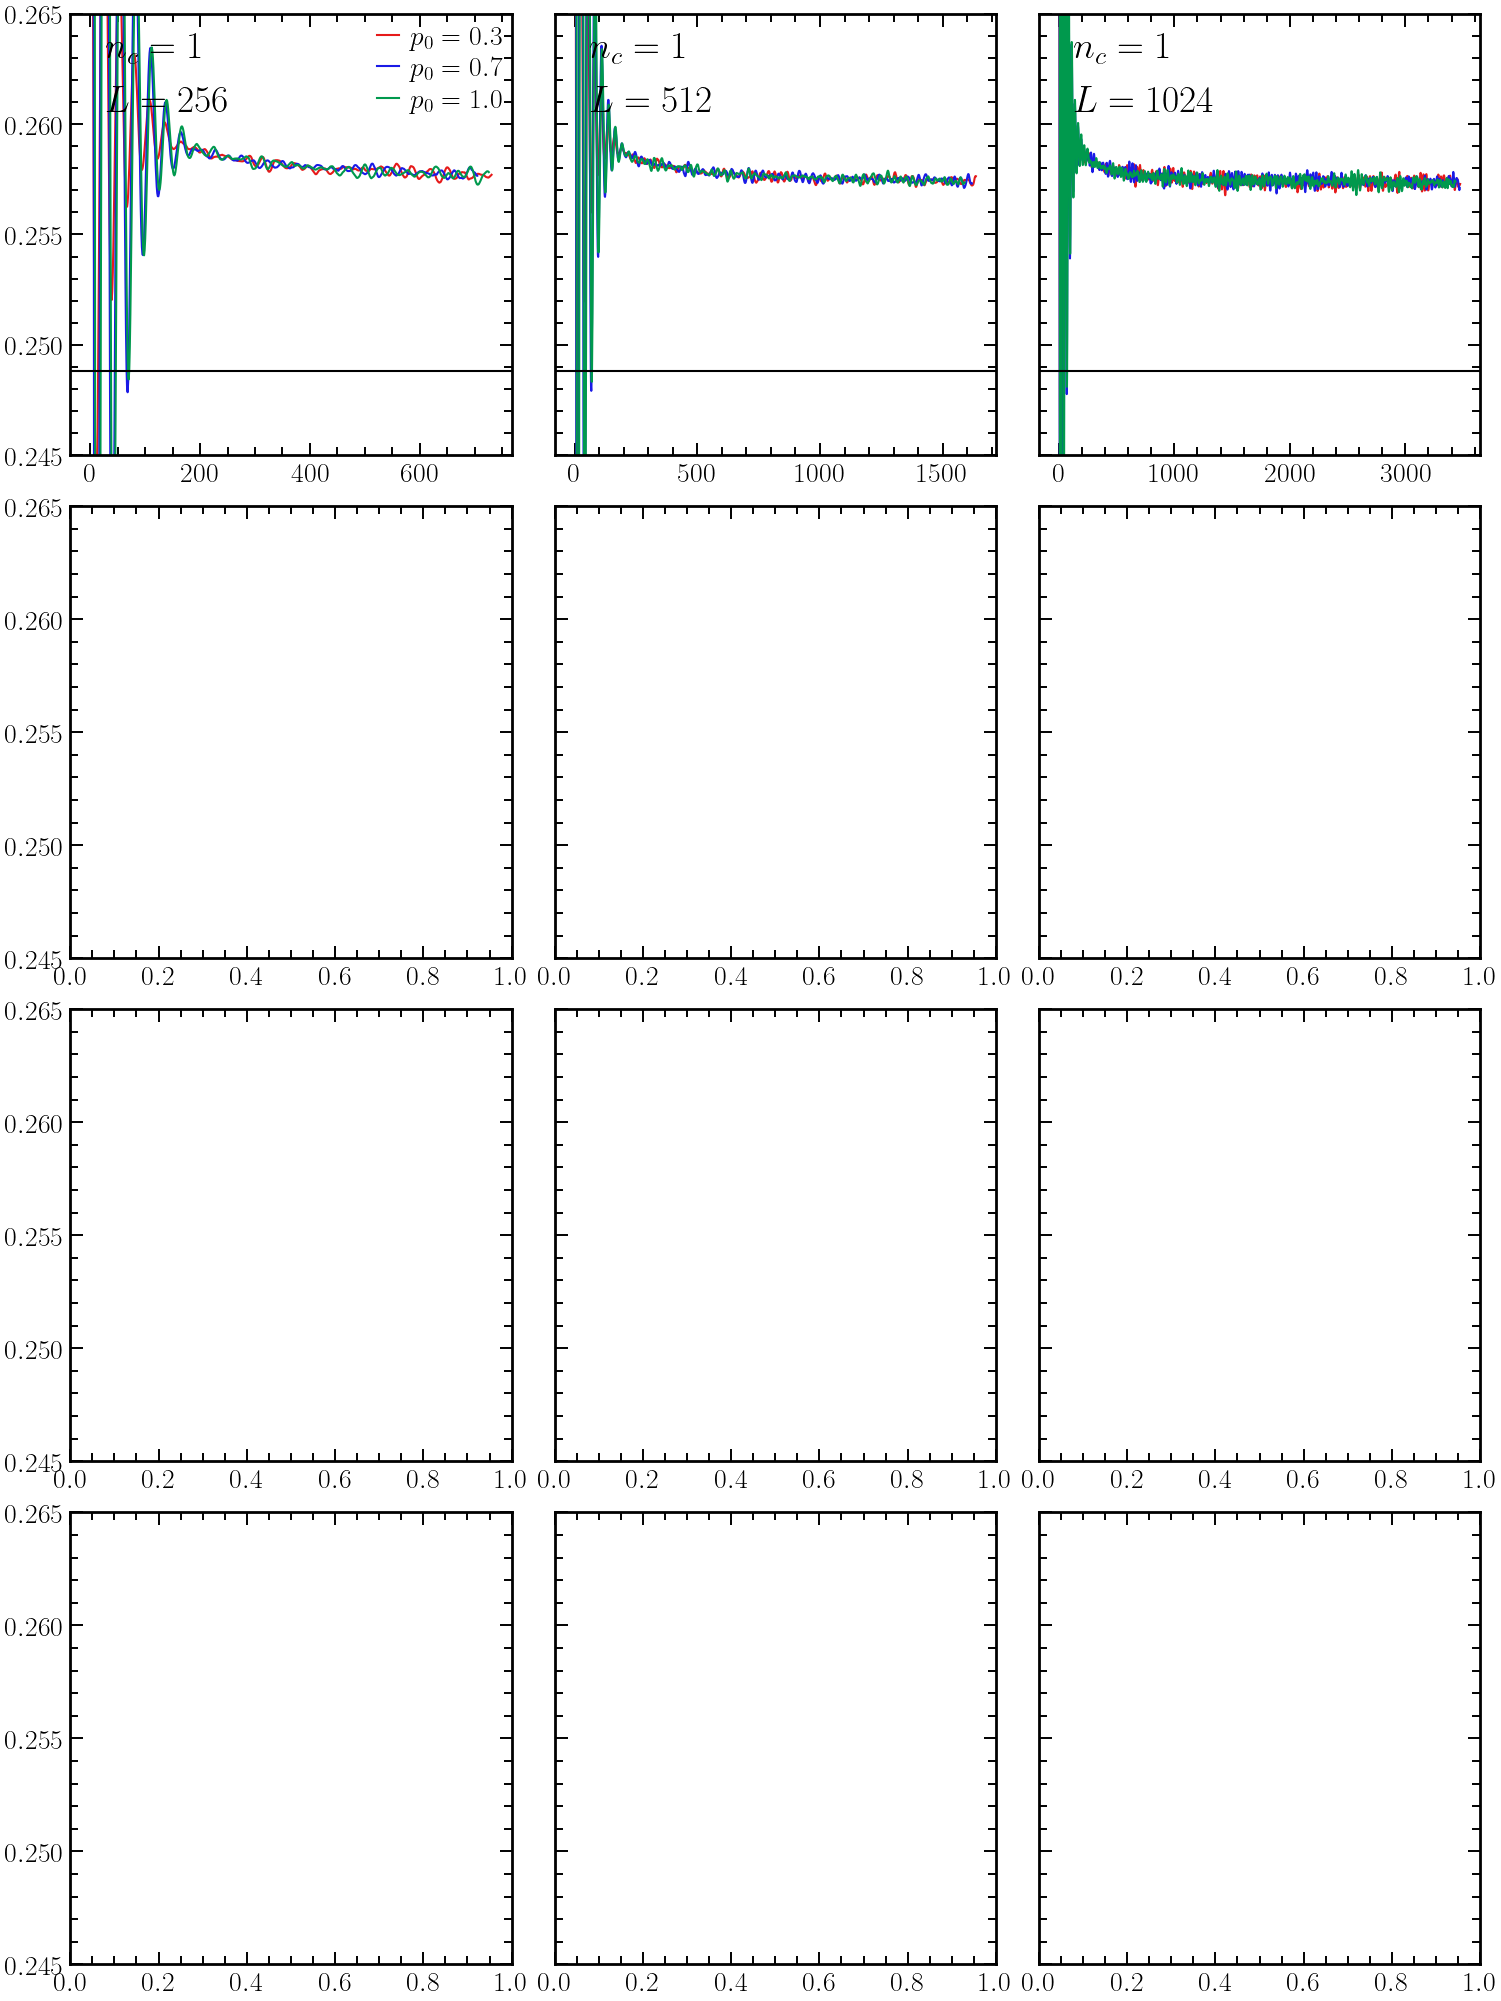

In [10]:
#fT = 0.05
#c = 0.01
fT = 0.1
c=0.15
L_lst = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]

base = 5
p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), len(L_lst), figsize=(3*base, 4*base), constrained_layout=True, sharey=True)
order_mean = 0
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
for idx_nc, nc in enumerate(nc_lst):
    for idx_L, L in enumerate(L_lst):
        ax = axes[idx_nc, idx_L]
        rho = 1/nc
        path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{fT:.6e}/c_{c:.6e}/rho_{rho:.4e}"
        fn = path + "/properties_mean_bundle.json"
        bundle = load_properties_bundle(fn)
        for idx_p0, p0 in enumerate(p0_values):
            data = bundle[p0]["orders"][order_mean]
            time = data["time"]
            pt_mean = data["pt_mean"]
            ax.plot(time, pt_mean, ls='solid', color=colors[idx_p0], label=f'$p_0 = {p0}$')
            t_max = max(t_max, max(time))
        ax.axhline(pc, color='k', ls='solid')
        ax.set_ylim(0.245, 0.265)
        ax.set_box_aspect(1)
        ax.text(0.08, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.text(0.08, 0.78, f'$L = {L}$', transform=ax.transAxes , fontsize=fs_l_fig)
        if idx_nc == 0 and idx_L == 0:
            ax.legend()

for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(0.86, 0.10, labels_fig[idx], transform=ax.transAxes , fontsize=fs_labels_fig)

for ax in axes[:,0]:
    ax.set_ylabel(r'$\langle p(t) \rangle_{samples}$')
for ax in axes[-1,:]:
    ax.set_xlabel(r'$t$')

#fig.suptitle(f"dim $= {dim}$, $f_T = {fT}$, $n_s = 1$, $c = {c}$", fontsize=30)
#plt.savefig(results_folder + f"/pt_multiply_L.svg")
plt.show()


## Height Effects ($z=L$, $z=2L$, $z=3L$)

Loading data for nc=2, ft=0.1
File not found: ../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/fT_constant/fT_2.000000e-01/c_1.500000e-01/rho_5.0000e-01/properties_mean_bundle.json
File not found: ../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/fT_constant/fT_3.000000e-01/c_1.500000e-01/rho_5.0000e-01/properties_mean_bundle.json
File not found: ../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/fT_constant/fT_4.000000e-01/c_1.500000e-01/rho_5.0000e-01/properties_mean_bundle.json
Loading data for nc=2, ft=0.1
Loading data for nc=2, ft=0.2
Loading data for nc=2, ft=0.3
Loading data for nc=2, ft=0.4
Loading data for nc=2, ft=0.1
Loading data for nc=2, ft=0.2
Loading data for nc=2, ft=0.3
Loading data for nc=2, ft=0.4
Loading data for nc=4, ft=0.1
File not found: ../SOP_data/published/bond_percolation/num_colors_4/dim_3/L_256/fT_constant/fT_2.000000e-01/c_1.500000e-01/rho_2.5000e-01/properties_mean_bundle.json
File not found: ../SOP_data/publishe

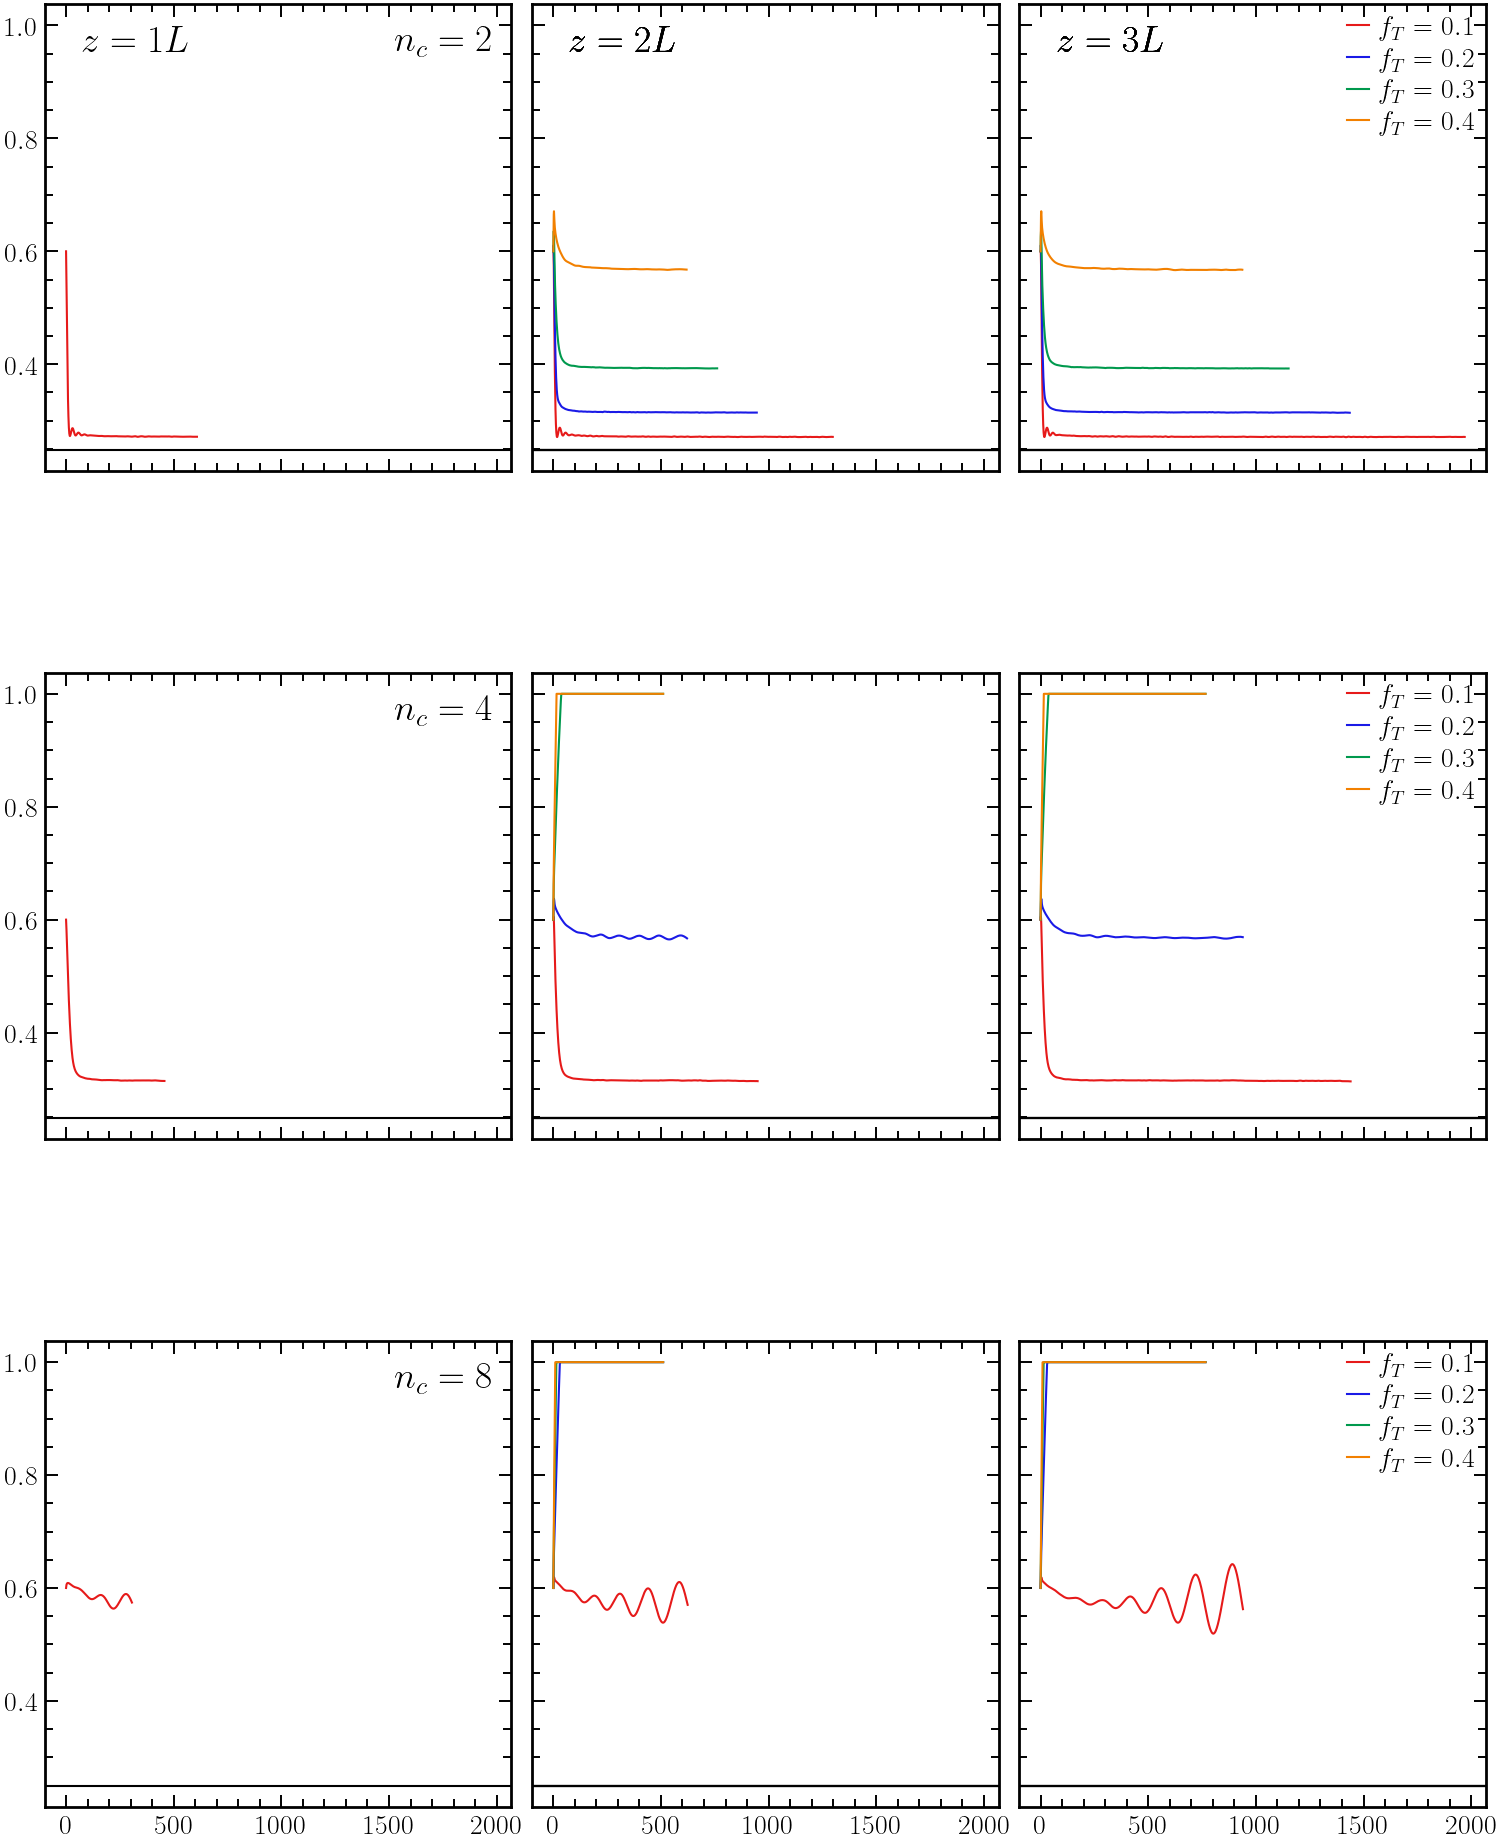

In [38]:
fT_lst = [0.1, 0.2, 0.3, 0.4]
c = 0.15
L = 256
dim = 3
nc_lst = [2, 4, 8]
p0 = 0.6
base = 5
#p0_values = [0.3, 0.7, 1.0]
fig, axes = plt.subplots(len(nc_lst), 3, figsize=(3*base, 4*base), constrained_layout=True, sharey=True, sharex=True)
order_mean = 0
pc = 0.24881182
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
labels_fig = [r'$(a)$', r'$(b)$', r'$(c)$',
              r'$(d)$', r'$(e)$', r'$(f)$',
              r'$(g)$', r'$(h)$', r'$(i)$',
              r'$(j)$', r'$(k)$', r'$(l)$',]

fs_labels_fig = 30
fs_l_fig = 27

t_max = 0
parms_list = []
for idx_nc, nc in enumerate(nc_lst):
    for index in range(3):
        ax = axes[idx_nc, index]
        for idx_ft, ft in enumerate(fT_lst):
        
            rho = 1/nc
            if(index == 0):
                path = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            elif(index == 1):
                path = f"../SOP_data/published_2L_stop/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            elif(index == 2):
                path = f"../SOP_data/published_3L_stop/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/fT_constant/fT_{ft:.6e}/c_{c:.6e}/rho_{rho:.4e}"
            
            fn = path + "/properties_mean_bundle.json"
            try:
                bundle = load_properties_bundle(fn)
                data = bundle[p0]["orders"][order_mean]
                time = data["time"]
                pt_mean = data["pt_mean"]
                ax.plot(time, pt_mean, ls='solid', color=colors[idx_ft], label=f'$f_T = {ft}$')
            except KeyError:
                print(f"File not found: {fn}")
                parms_list.append((nc, ft, path))
                continue
            except FileNotFoundError:
                print(f"File not found: {fn}")
                parms_list.append((nc, ft, path))
                continue
            print(f'Loading data for nc={nc}, ft={ft}')
            
            t_max = max(t_max, max(time))
            
            ax.axhline(pc, color='k', ls='solid')
            #ax.set_ylim(0.245, 0.265)
            ax.set_box_aspect(1)
            if(idx_nc == 0):
                ax.text(0.08, 0.9, f'$z = {index+1}L$', transform=ax.transAxes , fontsize=fs_l_fig)
            #ax.text(0.08, 0.78, f'$f_T = {ft}$', transform=ax.transAxes , fontsize=fs_l_fig)
            if index==2:
                ax.legend()
            if index==0:
                ax.text(0.75, 0.9, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
                #ax.set_ylabel(r'$\langle p(t) \rangle_{t>t_{\mathrmeq}}$')
plt.show()

In [43]:

print(len(parms_list))
for keys in parms_list:
    print(keys)

9
(2, 0.2, '../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/fT_constant/fT_2.000000e-01/c_1.500000e-01/rho_5.0000e-01')
(2, 0.3, '../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/fT_constant/fT_3.000000e-01/c_1.500000e-01/rho_5.0000e-01')
(2, 0.4, '../SOP_data/published/bond_percolation/num_colors_2/dim_3/L_256/fT_constant/fT_4.000000e-01/c_1.500000e-01/rho_5.0000e-01')
(4, 0.2, '../SOP_data/published/bond_percolation/num_colors_4/dim_3/L_256/fT_constant/fT_2.000000e-01/c_1.500000e-01/rho_2.5000e-01')
(4, 0.3, '../SOP_data/published/bond_percolation/num_colors_4/dim_3/L_256/fT_constant/fT_3.000000e-01/c_1.500000e-01/rho_2.5000e-01')
(4, 0.4, '../SOP_data/published/bond_percolation/num_colors_4/dim_3/L_256/fT_constant/fT_4.000000e-01/c_1.500000e-01/rho_2.5000e-01')
(8, 0.2, '../SOP_data/published/bond_percolation/num_colors_8/dim_3/L_256/fT_constant/fT_2.000000e-01/c_1.500000e-01/rho_1.2500e-01')
(8, 0.3, '../SOP_data/published/bond_percolation/num_colors_

## Order Percolation Effects

## Initial Activate Effects